# EDA-1

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Load the dataset dynamically
try:
    # Start from current working directory
    base_dir = Path.cwd()
    
    # Navigate to dataset folder (since notebook is in Machine_Learning)
    file_path = base_dir / 'eda_dataset' / 'BIKE_DETAILS.csv'
    
    # Read CSV
    df = pd.read_csv(file_path)
    
    print(f"Dataset loaded successfully from: {file_path}")

except FileNotFoundError:
    print("Error: 'BIKE_DETAILS.csv' not found. Please check the folder structure.")

# Set visual style for plots
sns.set_theme(style="whitegrid")

df.head(2)

Dataset loaded successfully from: /Users/vedikaagrawal/Documents/data_science_repo/Machine_Learning/eda_dataset/BIKE_DETAILS.csv


,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN


In [9]:
print("--- BASIC STATISTICS ---")

# 1. What is the range of selling prices in the dataset?
p_min, p_max = df['selling_price'].min(), df['selling_price'].max()
print(f"Q1: Range of selling prices: INR {p_min} to INR {p_max}")

# 2. What is the median selling price for bikes in the dataset?
print(f"Q2: Median selling price: INR {df['selling_price'].median()}")

# 3. What is the most common seller type?
print(f"Q3: Most common seller type: {df['seller_type'].mode()[0]}")

# 4. How many bikes have driven more than 50,000 kilometers?
high_km = len(df[df['km_driven'] > 50000])
print(f"Q4: Number of bikes driven > 50,000 km: {high_km}")

--- BASIC STATISTICS ---
Q1: Range of selling prices: INR 5000 to INR 760000
Q2: Median selling price: INR 45000.0
Q3: Most common seller type: Individual
Q4: Number of bikes driven > 50,000 km: 170


In [10]:
print("--- OWNERSHIP & MARKET TRENDS ---")

# 5. What is the average km_driven value for each ownership type?
print("Q5: Average km_driven by ownership type:")
print(df.groupby('owner')['km_driven'].mean())

# 6. What proportion of bikes are from the year 2015 or older?
prop_2015 = (len(df[df['year'] <= 2015]) / len(df)) * 100
print(f"\nQ6: Proportion of bikes from 2015 or older: {prop_2015:.2f}%")

# 7. What is the trend of missing values across the dataset?
print("\nQ7: Missing values per column:")
print(df.isnull().sum())

# 8. What is the highest ex_showroom_price recorded, and for which bike?
top_bike = df.loc[df['ex_showroom_price'].idxmax()]
print(f"\nQ8: Highest Ex-Showroom Price: {top_bike['ex_showroom_price']} (Bike: {top_bike['name']})")

# 9. What is the total number of bikes listed by each seller type?
print("\nQ9: Total bikes per seller type:")
print(df['seller_type'].value_counts())

--- OWNERSHIP & MARKET TRENDS ---
Q5: Average km_driven by ownership type:
owner
1st owner     32816.583333
2nd owner     39288.991870
3rd owner     33292.181818
4th owner    311500.000000
Name: km_driven, dtype: float64

Q6: Proportion of bikes from 2015 or older: 56.64%

Q7: Missing values per column:
name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64

Q8: Highest Ex-Showroom Price: 1278000.0 (Bike: Harley-Davidson Street Bob)

Q9: Total bikes per seller type:
seller_type
Individual    1055
Dealer           6
Name: count, dtype: int64


Q10: Visualizing Price vs KM for First Owners...


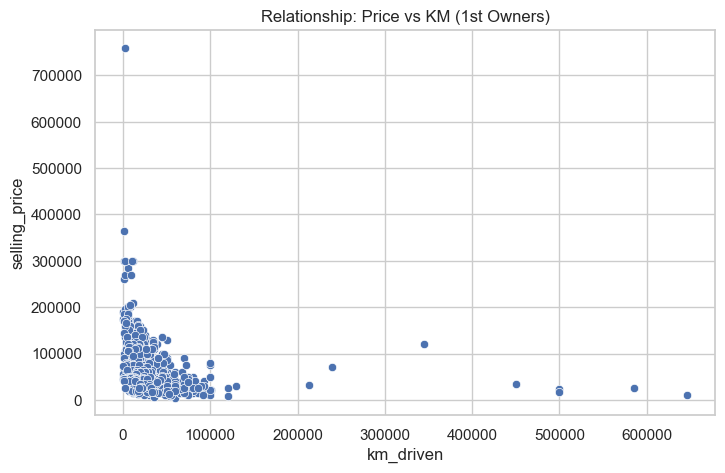

Q11: Removed 39 outliers. New dataset size: 1022
Q12: Visualizing Year vs Selling Price...


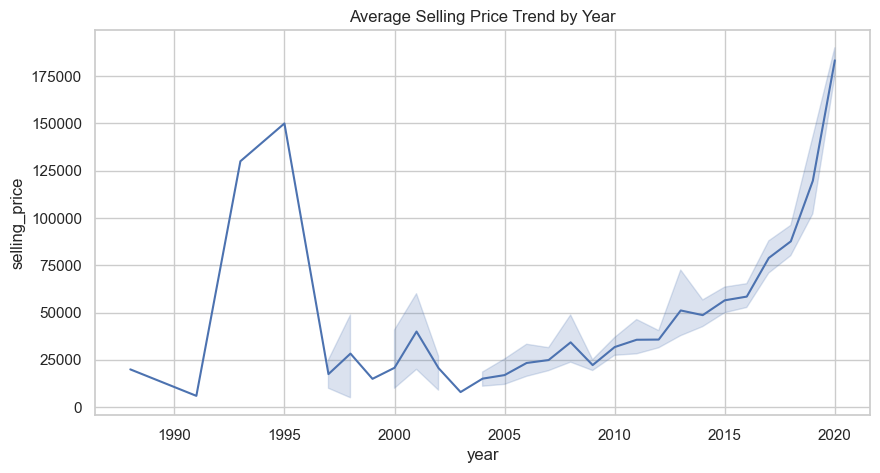

Q13: Average annual depreciation: INR 2426.75
Q14: Some premium bikes: <StringArray>
[ 'Royal Enfield Classic Gunmetal Grey',
 'Royal Enfield Bullet 350 [2007-2011]',
                        'Yamaha YZF R3',
                        'Jawa Standard',
        'Royal Enfield Thunderbird 350']
Length: 5, dtype: str...
Q15: Generating Correlation Heatmap...


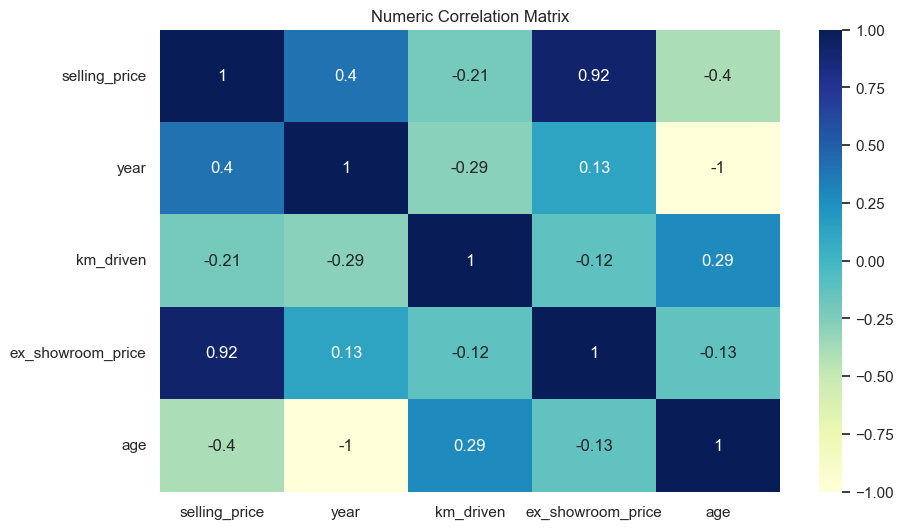

In [11]:
# 10. Relationship between selling_price and km_driven for first-owner bikes
print("Q10: Visualizing Price vs KM for First Owners...")
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df[df['owner'] == '1st owner'], x='km_driven', y='selling_price')
plt.title("Relationship: Price vs KM (1st Owners)")
plt.show()

# 11. Identify and remove outliers in the km_driven column using the IQR method
Q1 = df['km_driven'].quantile(0.25)
Q3 = df['km_driven'].quantile(0.75)
IQR = Q3 - Q1
df_filtered = df[(df['km_driven'] >= Q1 - 1.5*IQR) & (df['km_driven'] <= Q3 + 1.5*IQR)]
print(f"Q11: Removed {len(df) - len(df_filtered)} outliers. New dataset size: {len(df_filtered)}")

# 12. Bivariate analysis: year vs selling_price
print("Q12: Visualizing Year vs Selling Price...")
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='year', y='selling_price', estimator='mean')
plt.title("Average Selling Price Trend by Year")
plt.show()

# 13. Average depreciation based on bike age
# We assume current year is 2026 as per system time
df['age'] = 2026 - df['year']
# Depreciation = (Original Price - Selling Price) / Age
avg_dep = ((df['ex_showroom_price'] - df['selling_price']) / df['age']).mean()
print(f"Q13: Average annual depreciation: INR {avg_dep:.2f}")

# 14. Which bike names are priced significantly above the average for their year?
# Significant = more than 1.5x the mean price for that year
avg_by_year = df.groupby('year')['selling_price'].transform('mean')
premium_bikes = df[df['selling_price'] > (avg_by_year * 1.5)]['name'].unique()
print(f"Q14: Some premium bikes: {premium_bikes[:5]}...")

# 15. Correlation matrix for numeric columns and heatmap
print("Q15: Generating Correlation Heatmap...")
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='YlGnBu')
plt.title("Numeric Correlation Matrix")
plt.show()

# EDA-2

In [28]:
# Load the dataset dynamically
try:
    # Start from current working directory
    base_dir = Path.cwd()
    
    # Navigate to dataset folder (since notebook is in Machine_Learning)
    file_path = base_dir / 'eda_dataset' / 'Car Sale.csv'
    
    # Read CSV
    df = pd.read_csv(file_path)
    
    print(f"Dataset loaded successfully from: {file_path}")

except FileNotFoundError:
    print("Error: 'Car Sale.csv' not found. Please check the folder structure.")

# Set visual style for plots
sns.set_theme(style="whitegrid")

df.head(2)


Dataset loaded successfully from: /Users/vedikaagrawal/Documents/data_science_repo/Machine_Learning/eda_dataset/Car Sale.csv


,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora


--- DEALER & BRAND ANALYSIS ---
Q1: Average Selling Price per Dealer (Top 5):
Dealer_Name
U-Haul CO                28769.919006
Classic Chevy            28602.014446
Rabun Used Car Sales     28527.536177
Iceberg Rentals          28522.958533
Enterprise Rent A Car    28312.580800
Name: Price ($), dtype: float64

Q2: Brand with highest price variation: Lincoln (Std Dev: 19658.05)

Q3: Generating Boxplot for Transmission vs Price...


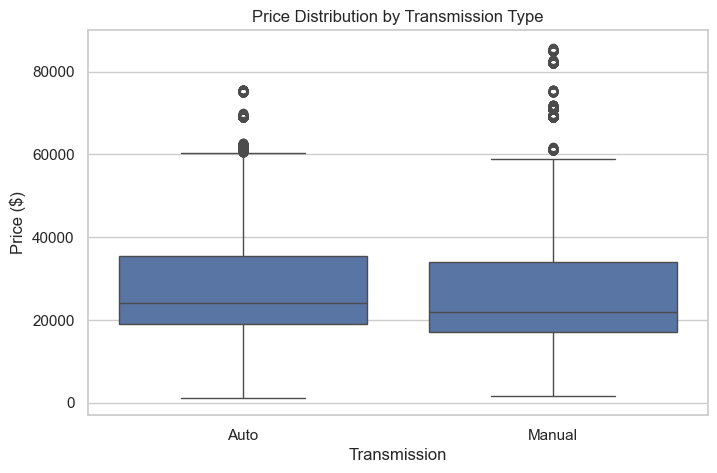


Q4: Generating Boxplot for Regional Price Distribution...


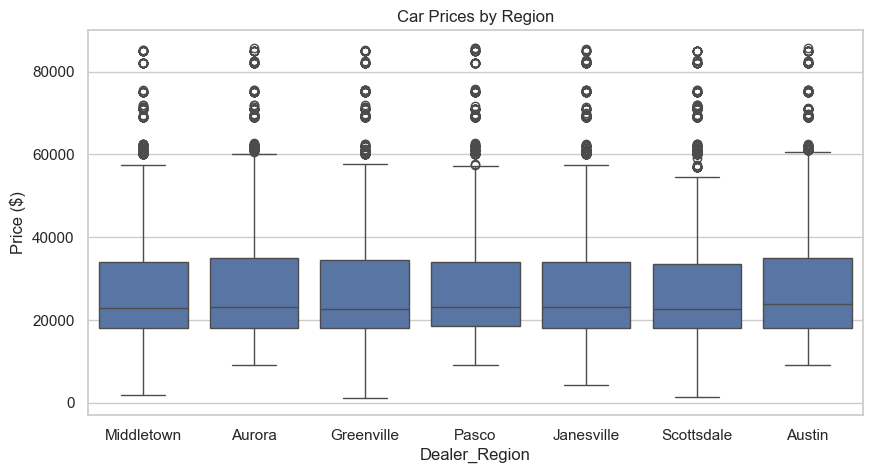


Q5: Car counts by Body Style:
Body Style
SUV          6374
Hatchback    6128
Sedan        4488
Passenger    3945
Hardtop      2971
Name: count, dtype: int64


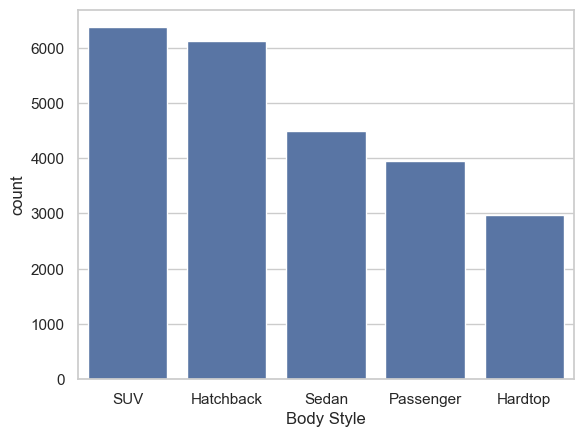

In [19]:
print("--- DEALER & BRAND ANALYSIS ---")

# 1. Average selling price of cars for each dealer
avg_price_dealer = df.groupby('Dealer_Name')['Price ($)'].mean().sort_values(ascending=False)
print("Q1: Average Selling Price per Dealer (Top 5):")
print(avg_price_dealer.head())

# 2. Which car brand (Company) has the highest variation in prices?
brand_variation = df.groupby('Company')['Price ($)'].std().sort_values(ascending=False)
print(f"\nQ2: Brand with highest price variation: {brand_variation.index[0]} (Std Dev: {brand_variation.iloc[0]:.2f})")

# 3. Distribution of car prices for each transmission type (Boxplot)
print("\nQ3: Generating Boxplot for Transmission vs Price...")
plt.figure(figsize=(8, 5))
sns.boxplot(x='Transmission', y='Price ($)', data=df)
plt.title("Price Distribution by Transmission Type")
plt.show()

# 4. Distribution of car prices across different regions
print("\nQ4: Generating Boxplot for Regional Price Distribution...")
plt.figure(figsize=(10, 5))
sns.boxplot(x='Dealer_Region', y='Price ($)', data=df)
plt.title("Car Prices by Region")
plt.show()

# 5. Distribution of cars based on body styles
print("\nQ5: Car counts by Body Style:")
body_style_counts = df['Body Style'].value_counts()
print(body_style_counts)
sns.countplot(data=df, x='Body Style', order=body_style_counts.index)
plt.show()

--- CUSTOMER & TECHNICAL ANALYSIS ---
Q6: Average Price by Gender:
Gender
Female    28277.265270
Male      28039.429407
Name: Price ($), dtype: float64

Q7: Sales Count by Region:
Dealer_Region
Austin        4135
Janesville    3821
Scottsdale    3433
Pasco         3131
Aurora        3130
Middletown    3128
Greenville    3128
Name: count, dtype: int64

Q8: Avg Price by Engine Type (Top 5):
Engine
Overhead Camshaft            27914.710631
DoubleÂ Overhead Camshaft    28248.525972
Name: Price ($), dtype: float64

Q9: Avg Price by Income Bracket:
Income_Bracket
Low          27954.276468
Medium       27974.380371
High         28288.664936
Very High    28144.058223
Name: Price ($), dtype: float64

Q10: Top 5 Models:
Model
Diamante      418
Prizm         411
Silhouette    411
Passat        391
Ram Pickup    383
Name: count, dtype: int64


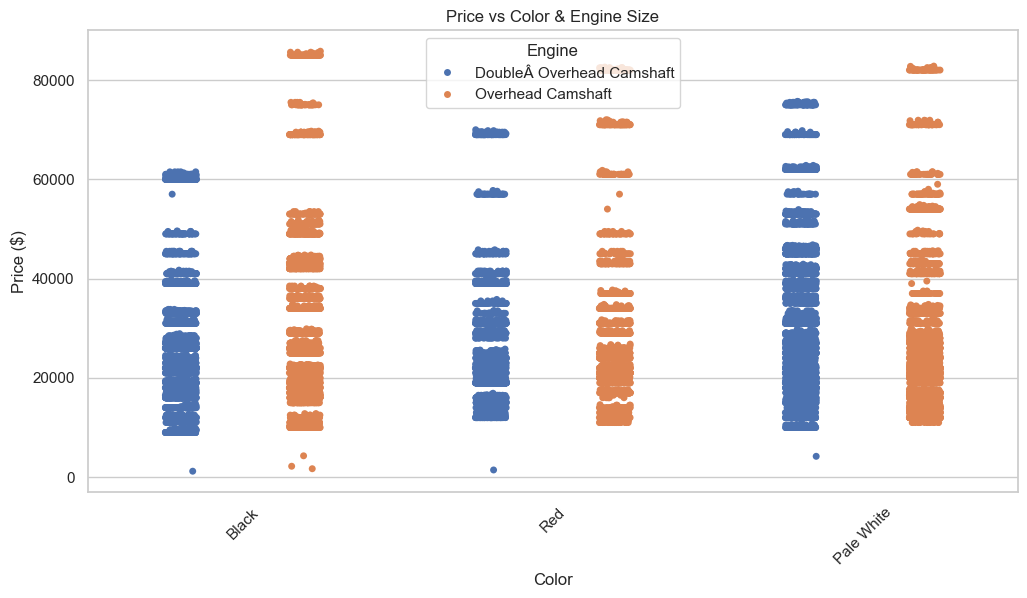

In [20]:
print("--- CUSTOMER & TECHNICAL ANALYSIS ---")

# 6. Average selling price by customer gender and annual income
# Note: Income is numeric, so we often look at the correlation or group by gender
gender_price = df.groupby('Gender')['Price ($)'].mean()
print(f"Q6: Average Price by Gender:\n{gender_price}")

# 7. Distribution of car prices and sales count by region
print("\nQ7: Sales Count by Region:")
print(df['Dealer_Region'].value_counts())

# 8. How does the average car price differ between cars with different engine sizes?
avg_price_engine = df.groupby('Engine')['Price ($)'].mean().sort_values()
print(f"\nQ8: Avg Price by Engine Type (Top 5):\n{avg_price_engine.tail()}")

# 9. How do car prices vary based on customer's annual income bracket?
df['Income_Bracket'] = pd.qcut(df['Annual Income'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
print("\nQ9: Avg Price by Income Bracket:")
print(df.groupby('Income_Bracket')['Price ($)'].mean())

# 10. Top 5 car models with highest number of sales
top_5_models = df['Model'].value_counts().head(5)
print(f"\nQ10: Top 5 Models:\n{top_5_models}")

# 11. Car price variation with engine size across different car colors
plt.figure(figsize=(12, 6))
sns.stripplot(x='Color', y='Price ($)', hue='Engine', data=df, dodge=True)
plt.title("Price vs Color & Engine Size")
plt.xticks(rotation=45)
plt.show()

--- TRENDS & CORRELATIONS ---


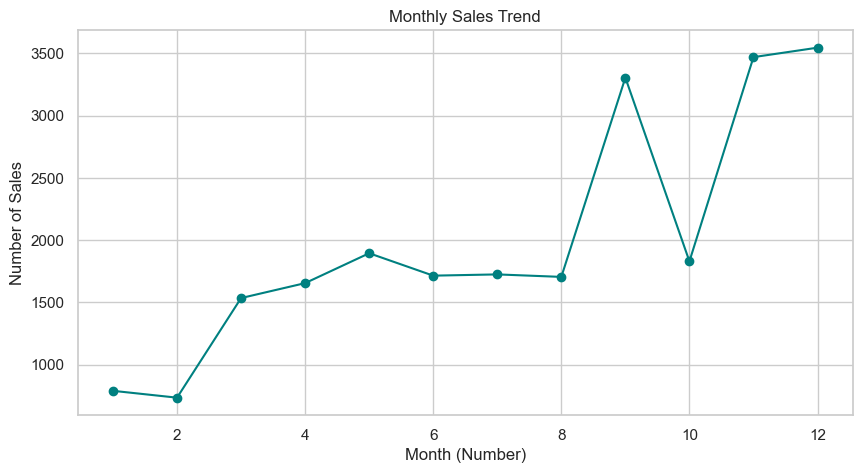

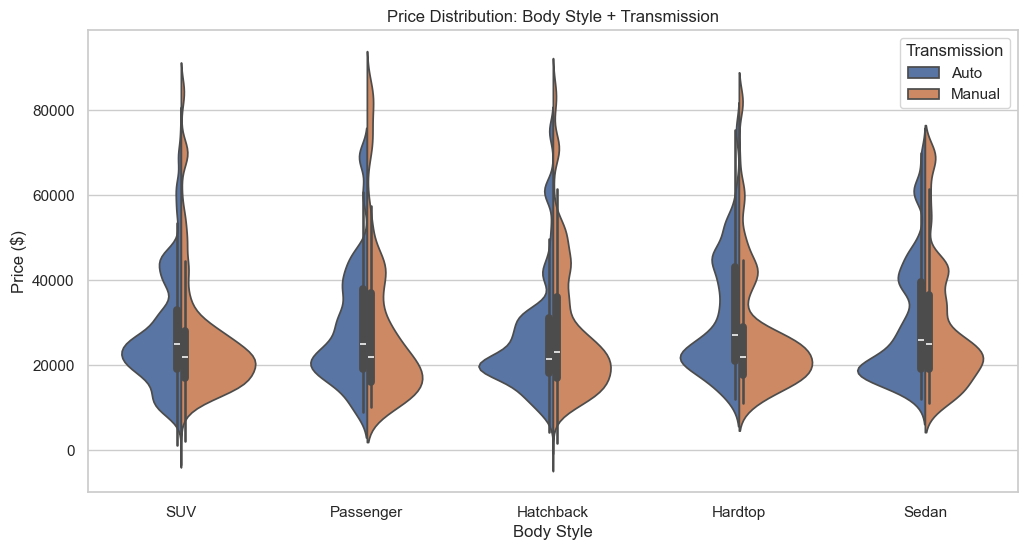


Q14: Correlation Matrix (Numeric Features):
               Price ($)  Annual Income
Price ($)       1.000000       0.012065
Annual Income   0.012065       1.000000

Q15: Sample of Model vs Engine Price Pivot Table:
Engine  DoubleÂ Overhead Camshaft  Overhead Camshaft
Model                                               
3-Sep                37986.380117                NaN
3000GT               22764.326923       21770.659864
300M                 21394.888889                NaN
323i                 16744.632287       21038.162162
328i                 21069.149606       38676.177215


In [22]:
print("--- TRENDS & CORRELATIONS ---")

# 12. Is there any seasonal trend in car sales based on the date of sale?
# Ensure the Date column is converted first
df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.month
monthly_sales = df.groupby('Month').size()

plt.figure(figsize=(10, 5))
monthly_sales.plot(kind='line', marker='o', color='teal')
plt.title("Monthly Sales Trend")
plt.xlabel("Month (Number)")
plt.ylabel("Number of Sales")
plt.grid(True)
plt.show()

# 13. Price distribution for combinations of body style and transmission
plt.figure(figsize=(12, 6))
sns.violinplot(x='Body Style', y='Price ($)', hue='Transmission', data=df, split=True)
plt.title("Price Distribution: Body Style + Transmission")
plt.show()

# 14. Correlation between car price, engine size, and annual income
# Note: We must ensure columns are numeric for correlation
print("\nQ14: Correlation Matrix (Numeric Features):")
# We map engine types to numbers if they are strings like 'V6' to analyze them
corr_cols = ['Price ($)', 'Annual Income'] 
print(df[corr_cols].corr())

# 15. Average car price vary across different car models and engine types
model_engine_pivot = df.pivot_table(values='Price ($)', index='Model', columns='Engine', aggfunc='mean')
print("\nQ15: Sample of Model vs Engine Price Pivot Table:")
print(model_engine_pivot.iloc[:5, :5]) # Showing a small slice for readability

# EDA-3

In [32]:
# Load the dataset dynamically
try:
    # Start from current working directory
    base_dir = Path.cwd()
    
    # Navigate to dataset folder (since notebook is in Machine_Learning)
    file_path = base_dir / 'eda_dataset' / 'amazon.csv'
    
    # Read CSV
    df = pd.read_csv(file_path)
    
    print(f"Dataset loaded successfully from: {file_path}")

except FileNotFoundError:
    print("Error: 'amazon.csv' not found. Please check the folder structure.")

# Set visual style for plots
sns.set_theme(style="whitegrid")

df.head(2)


Dataset loaded successfully from: /Users/vedikaagrawal/Documents/data_science_repo/Machine_Learning/eda_dataset/amazon.csv


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...


In [34]:
print("--- CATEGORY & RATING ANALYSIS ---")

# ✅ Step 1: Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# ✅ Step 2: Fix data types

# Convert rating to numeric
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Clean rating_count (remove commas and convert)
df['rating_count'] = df['rating_count'].astype(str).str.replace(',', '')
df['rating_count'] = pd.to_numeric(df['rating_count'], errors='coerce')

# Remove rows where important values are missing
df_clean = df.dropna(subset=['category', 'rating', 'rating_count'])


# -------------------------------
# 1. Average rating per category
# -------------------------------
avg_rating_cat = (
    df_clean
    .groupby('category')['rating']
    .mean()
    .sort_values(ascending=False)
)

print("Q1: Average Rating per Category (Top 5):")
print(avg_rating_cat.head())


# ---------------------------------------------
# 2. Top product by rating_count in each category
# ---------------------------------------------
top_rated_products = df_clean.loc[
    df_clean.groupby('category')['rating_count'].idxmax()
]

print("\nQ2: Top products by Rating Count in each Category (Sample):")
print(top_rated_products[['category', 'product_name', 'rating_count']].head())


# ---------------------------------------------
# 9. Top 5 categories based on highest ratings
# ---------------------------------------------
print("\nQ9: Top 5 Categories with highest average ratings:")
print(avg_rating_cat.head(5))

--- CATEGORY & RATING ANALYSIS ---
Q1: Average Rating per Category (Top 5):
category
Computers&Accessories|Tablets                                               4.6
Computers&Accessories|NetworkingDevices|NetworkAdapters|PowerLANAdapters    4.5
Electronics|Cameras&Photography|Accessories|Film                            4.5
Electronics|HomeAudio|MediaStreamingDevices|StreamingClients                4.5
OfficeProducts|OfficeElectronics|Calculators|Basic                          4.5
Name: rating, dtype: float64

Q2: Top products by Rating Count in each Category (Sample):
                                               category  \
1157  Car&Motorbike|CarAccessories|InteriorAccessori...   
695   Computers&Accessories|Accessories&Peripherals|...   
906   Computers&Accessories|Accessories&Peripherals|...   
748   Computers&Accessories|Accessories&Peripherals|...   
844   Computers&Accessories|Accessories&Peripherals|...   

                                           product_name  rating_count 

--- PRICING & DISCOUNTS ---
Q3: Generating Distribution Plot for Prices...


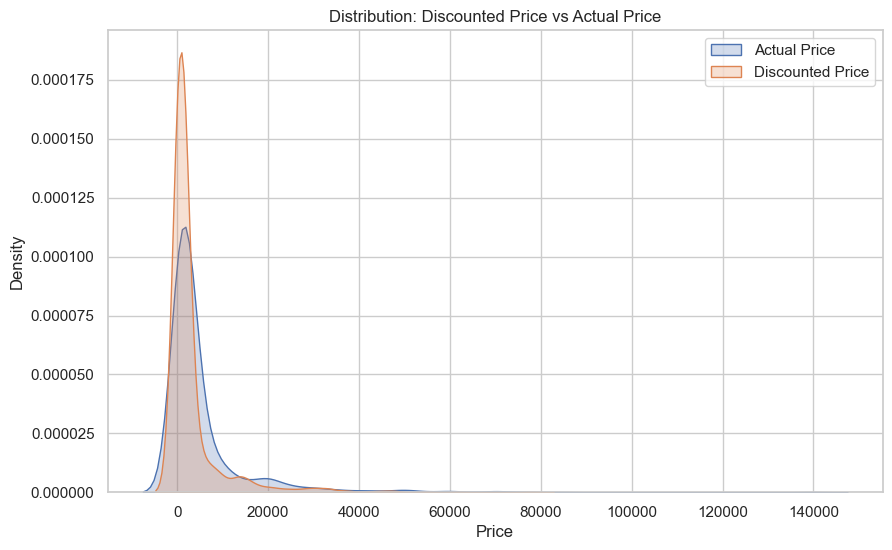


Q4: Average Discount % by Category (Top 5):
category
Electronics|Mobiles&Accessories|MobileAccessories|Décor|PhoneCharms                                              90.0
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|CableConnectionProtectors                       90.0
Electronics|Headphones,Earbuds&Accessories|Earpads                                                               90.0
Electronics|Headphones,Earbuds&Accessories|Adapters                                                              88.0
Computers&Accessories|Accessories&Peripherals|Keyboards,Mice&InputDevices|Keyboard&MiceAccessories|DustCovers    87.5
Name: discount_percentage, dtype: float64

Q8: Correlation between Discounted Price and Rating: 0.1203


In [35]:
print("--- PRICING & DISCOUNTS ---")

# ✅ Step 1: Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# ✅ Step 2: Clean price columns (remove ₹, commas, etc.)
df['actual_price'] = df['actual_price'].astype(str).str.replace('₹', '').str.replace(',', '')
df['discounted_price'] = df['discounted_price'].astype(str).str.replace('₹', '').str.replace(',', '')

df['actual_price'] = pd.to_numeric(df['actual_price'], errors='coerce')
df['discounted_price'] = pd.to_numeric(df['discounted_price'], errors='coerce')

# ✅ Step 3: Clean discount percentage
df['discount_percentage'] = df['discount_percentage'].astype(str).str.replace('%', '')
df['discount_percentage'] = pd.to_numeric(df['discount_percentage'], errors='coerce')

# ✅ Step 4: Clean rating (for correlation)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Drop rows with missing important values
df_clean = df.dropna(subset=[
    'actual_price', 
    'discounted_price', 
    'discount_percentage', 
    'rating', 
    'category'
])


# ---------------------------------------------
# 3. Distribution of discounted vs actual prices
# ---------------------------------------------
print("Q3: Generating Distribution Plot for Prices...")

plt.figure(figsize=(10, 6))
sns.kdeplot(df_clean['actual_price'], label='Actual Price', fill=True)
sns.kdeplot(df_clean['discounted_price'], label='Discounted Price', fill=True)

plt.title("Distribution: Discounted Price vs Actual Price")
plt.xlabel("Price")
plt.legend()
plt.show()


# ---------------------------------------------
# 4. Average discount % across categories
# ---------------------------------------------
avg_discount_cat = (
    df_clean
    .groupby('category')['discount_percentage']
    .mean()
    .sort_values(ascending=False)
)

print("\nQ4: Average Discount % by Category (Top 5):")
print(avg_discount_cat.head())


# ---------------------------------------------
# 8. Correlation between discounted_price & rating
# ---------------------------------------------
price_rating_corr = df_clean['discounted_price'].corr(df_clean['rating'])

print(f"\nQ8: Correlation between Discounted Price and Rating: {price_rating_corr:.4f}")

In [43]:
print("--- POPULARITY & INSIGHTS ---")


# ---------------------------------------------
# 5. Most popular product names
# ---------------------------------------------
print("\nQ5: Most Frequently Listed Products\n")

popular_products = df_clean['product_name'].value_counts().head(5)

for i, (name, count) in enumerate(popular_products.items(), 1):
    print(f"{i}. {name[:60]}...  →  {count} listings")


# ---------------------------------------------
# 6. Most popular product keywords
# ---------------------------------------------
from collections import Counter
import re

print("\nQ6: Most Common Keywords in Product Names\n")

all_names = " ".join(df_clean['product_name']).lower()
words = re.findall(r'\w+', all_names)

# Optional stopwords
stopwords = {'with', 'from', 'this', 'that', 'your', 'have', 'for', 'and'}

common_keywords = Counter(
    [w for w in words if len(w) > 3 and w not in stopwords]
).most_common(10)

for i, (word, freq) in enumerate(common_keywords, 1):
    print(f"{i}. {word}  →  {freq} times")


# ---------------------------------------------
# 7. Most popular product reviews
# ---------------------------------------------
print("\nQ7: Top Products by Rating Count\n")

top_reviews = df_clean.sort_values(
    by='rating_count', ascending=False
)[['product_name', 'rating_count']].head(5)

for i, row in enumerate(top_reviews.itertuples(), 1):
    print(f"{i}. {row.product_name[:60]}...  →  {int(row.rating_count):,} ratings")


--- POPULARITY & INSIGHTS ---

Q5: Most Frequently Listed Products

1. Fire-Boltt Ninja Call Pro Plus 1.83" Smart Watch with Blueto...  →  5 listings
2. Fire-Boltt Phoenix Smart Watch with Bluetooth Calling 1.3",1...  →  4 listings
3. Wayona Nylon Braided USB to Lightning Fast Charging and Data...  →  3 listings
4. Ambrane Unbreakable 60W / 3A Fast Charging 1.5m Braided Type...  →  3 listings
5. Sounce Fast Phone Charging Cable & Data Sync USB Cable Compa...  →  3 listings

Q6: Most Common Keywords in Product Names

1. black  →  528 times
2. cable  →  412 times
3. charging  →  245 times
4. type  →  241 times
5. fast  →  210 times
6. smart  →  175 times
7. white  →  169 times
8. compatible  →  145 times
9. data  →  135 times
10. wireless  →  119 times

Q7: Top Products by Rating Count

1. AmazonBasics Flexible Premium HDMI Cable (Black, 4K@60Hz, 18...  →  426,973 ratings
2. Amazon Basics High-Speed HDMI Cable, 6 Feet (2-Pack),Black...  →  426,973 ratings
3. Amazon Basics High-Speed HDMI

In [44]:
# ---------------------------------------------
# 10. Improvement opportunities
# ---------------------------------------------
print("\nQ10: Improvement Opportunities\n")

median_price = df_clean['actual_price'].median()

low_rated_premium = df_clean[
    (df_clean['actual_price'] > median_price) &
    (df_clean['rating'] < 3.5)
]

print(f"Total high-priced but low-rated products: {len(low_rated_premium)}")

# Show sample
print("\nSample Products:")
sample = low_rated_premium[['product_name', 'actual_price', 'rating']].head(3)

for i, row in enumerate(sample.itertuples(), 1):
    print(f"{i}. {row.product_name[:50]}...")
    print(f"   Price: ₹{row.actual_price:,.0f} | Rating: {row.rating}")


Q10: Improvement Opportunities

Total high-priced but low-rated products: 19

Sample Products:
1. SKYWALL 81.28 cm (32 inches) HD Ready Smart LED TV...
   Price: ₹19,125 | Rating: 3.4
2. 7SEVEN® Bluetooth Voice Command Remote for Xiaomi ...
   Price: ₹1,999 | Rating: 3.3
3. 7SEVEN Compatible LG TV Remote Suitable for LG Non...
   Price: ₹1,999 | Rating: 3.0


# EDA-4

In [45]:
# Load the dataset dynamically
try:
    # Start from current working directory
    base_dir = Path.cwd()
    
    # Navigate to dataset folder (since notebook is in Machine_Learning)
    file_path = base_dir / 'eda_dataset' / 'spotify.csv'
    
    # Read CSV
    df = pd.read_csv(file_path)
    
    print(f"Dataset loaded successfully from: {file_path}")

except FileNotFoundError:
    print("Error: 'spotify.csv' not found. Please check the folder structure.")

# Set visual style for plots
sns.set_theme(style="whitegrid")

df.head(2)


Dataset loaded successfully from: /Users/vedikaagrawal/Documents/data_science_repo/Machine_Learning/eda_dataset/spotify.csv


,Artist,Track Name,Popularity,Duration (ms),Track ID
0,Drake,Rich Baby Daddy (feat. Sexyy Red & SZA),92,319191,1yeB8MUNeLo9Ek1UEpsyz6
1,Drake,One Dance,91,173986,1zi7xx7UVEFkmKfv06H8x0


Q2: Visualizing Popularity Distribution...


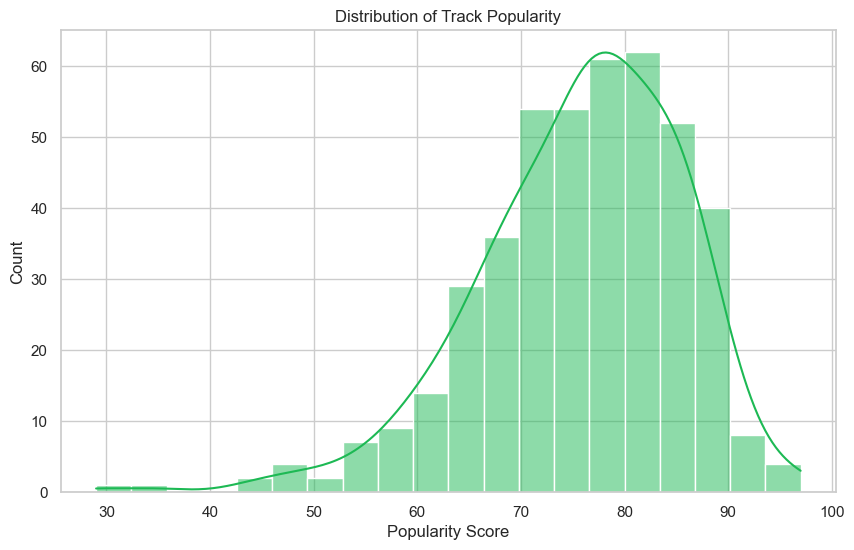

Q3: Visualizing Popularity vs Duration...


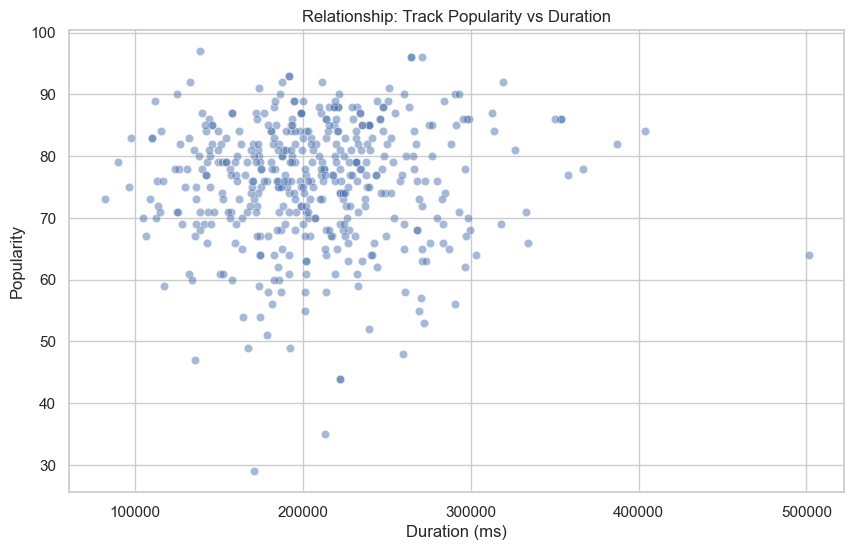

In [46]:
# 2. What is the distribution of popularity among the tracks? Visualize using a histogram.
print("Q2: Visualizing Popularity Distribution...")
plt.figure(figsize=(10, 6))
sns.histplot(df['Popularity'], bins=20, kde=True, color='#1DB954') # Spotify Green
plt.title("Distribution of Track Popularity")
plt.xlabel("Popularity Score")
plt.show()

# 3. Relationship between popularity and duration of tracks? (Scatter plot)
print("Q3: Visualizing Popularity vs Duration...")
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Duration (ms)', y='Popularity', alpha=0.5)
plt.title("Relationship: Track Popularity vs Duration")
plt.show()

Q4: Artist Track Counts...


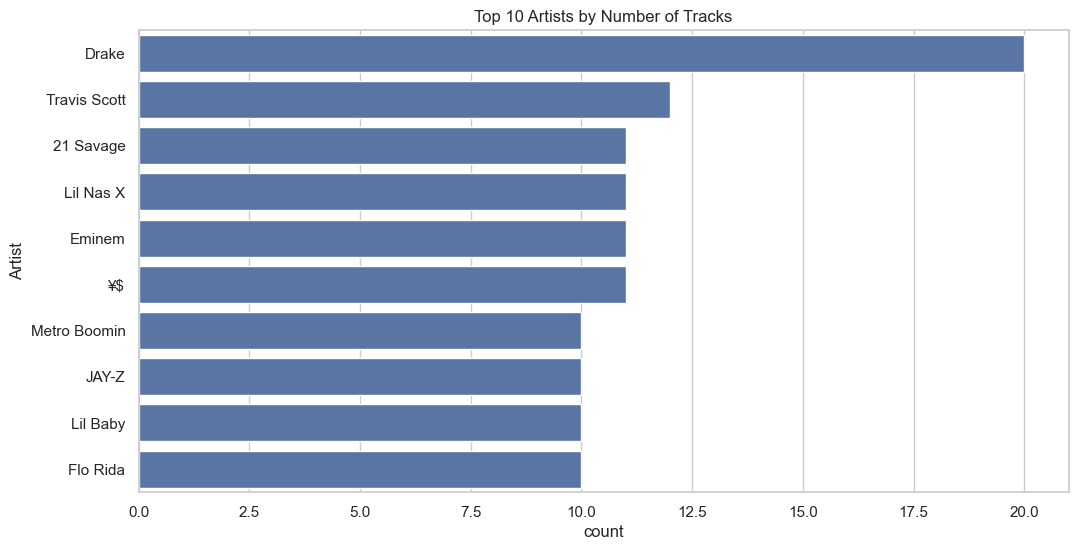


Q5: Top 5 Least Popular Tracks:
             Artist                     Track Name  Popularity
207          Pressa  Attachments (feat. Coi Leray)          29
231   Justin Bieber                     Intentions          35
413  French Montana                Splash Brothers          44
435  French Montana                Splash Brothers          44
225        Lil Baby                  On Me - Remix          47

Q6: Top 5 Artists by Average Popularity:
Artist
cassö           92.000000
Trueno          89.000000
David Guetta    87.000000
Travis Scott    87.000000
¥$              86.090909
Name: Popularity, dtype: float64

Q7: Signature Tracks for Top 5 Artists:
Artist: cassö | Track: Prada (Score: 92)
Artist: Trueno | Track: Mamichula - con Nicki Nicole (Score: 89)
Artist: David Guetta | Track: Baby Don't Hurt Me (Score: 87)
Artist: Travis Scott | Track: FE!N (feat. Playboi Carti) (Score: 93)
Artist: ¥$ | Track: CARNIVAL (Score: 96)


In [47]:
# 4. Which artist has the highest number of tracks? Display using a countplot.
print("Q4: Artist Track Counts...")
top_artists_list = df['Artist'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.countplot(data=df[df['Artist'].isin(top_artists_list.index)], 
              y='Artist', order=top_artists_list.index)
plt.title("Top 10 Artists by Number of Tracks")
plt.show()

# 5. What are the top 5 least popular tracks? (Artist and Track Name)
print("\nQ5: Top 5 Least Popular Tracks:")
least_popular = df.nsmallest(5, 'Popularity')[['Artist', 'Track Name', 'Popularity']]
print(least_popular)

# 6. Among the top 5 most popular artists, which has the highest average popularity?
# Define 'most popular artists' as those with the highest avg popularity score
top_5_popular_artists = df.groupby('Artist')['Popularity'].mean().nlargest(5)
print("\nQ6: Top 5 Artists by Average Popularity:")
print(top_5_popular_artists)

# 7. For the top 5 most popular artists, what are their most popular tracks?
print("\nQ7: Signature Tracks for Top 5 Artists:")
for artist in top_5_popular_artists.index:
    top_track = df[df['Artist'] == artist].nlargest(1, 'Popularity')[['Track Name', 'Popularity']]
    print(f"Artist: {artist} | Track: {top_track.iloc[0,0]} (Score: {top_track.iloc[0,1]})")

Q8: Generating Pair Plot for Numerical Variables...


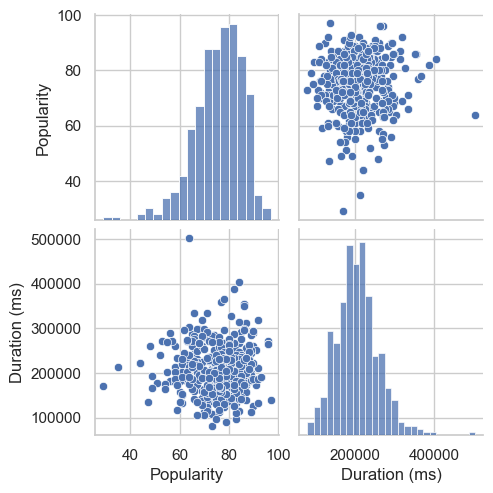

Q9: Track Duration Variation across Top Artists...


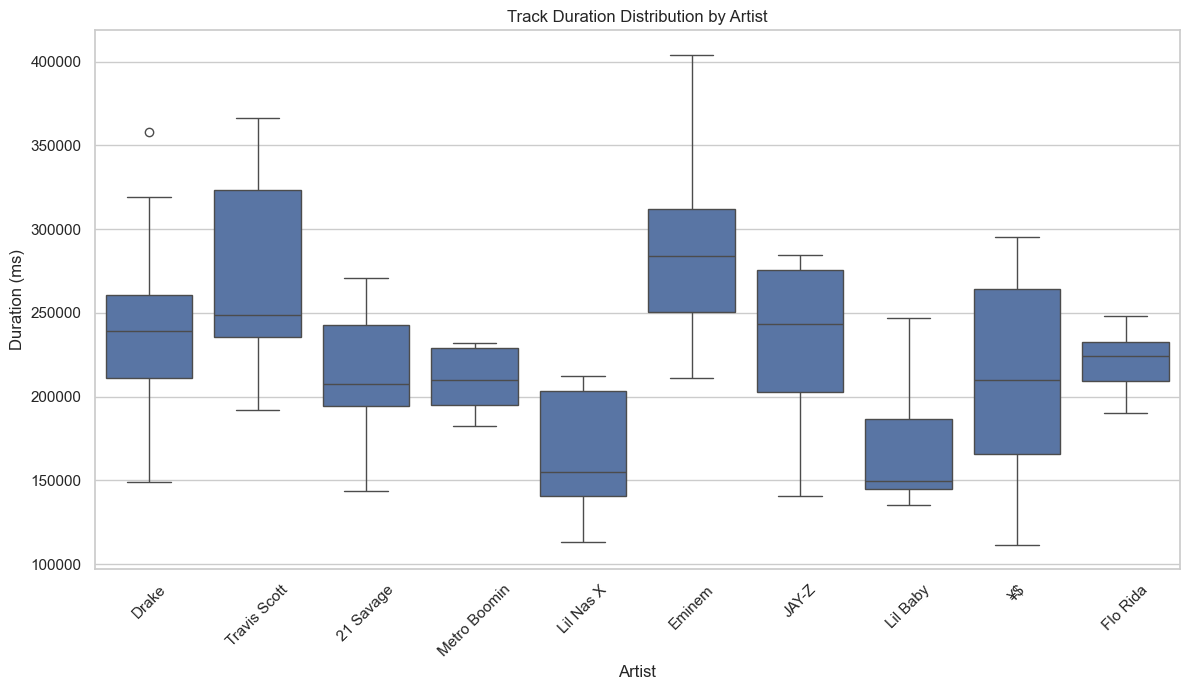

Q10: Popularity Distribution across Top Artists...


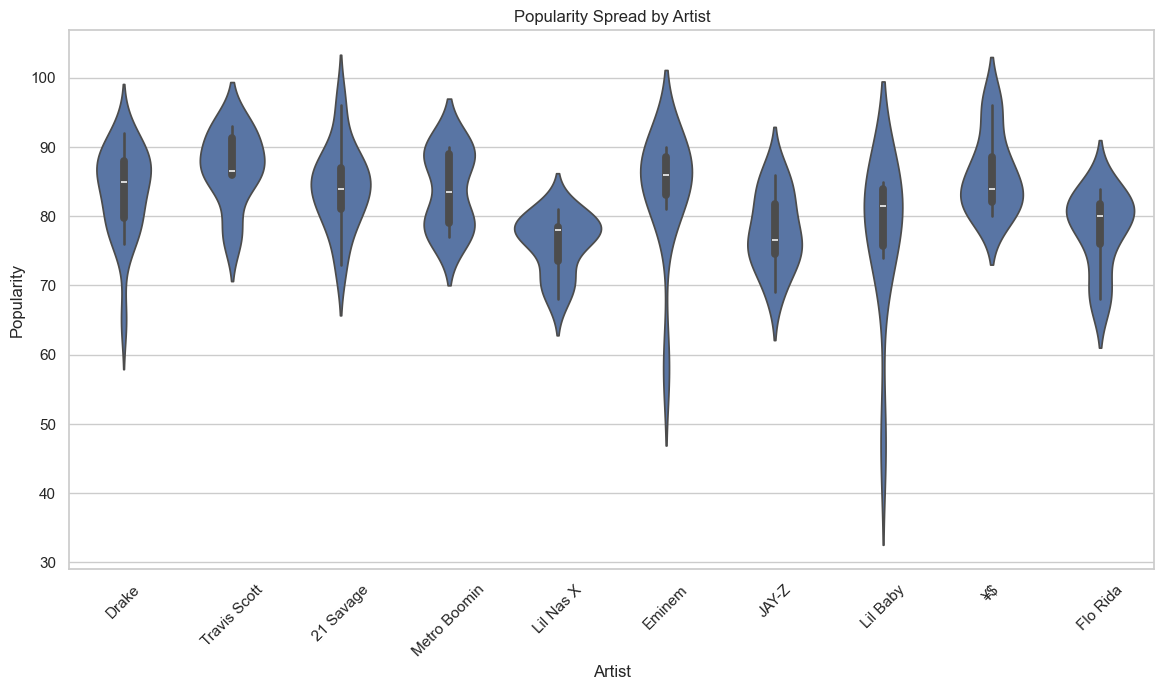

In [48]:
# 8. Visualize relationships between multiple numerical variables (Pair plot)
print("Q8: Generating Pair Plot for Numerical Variables...")
# Selecting only numeric columns
numeric_cols = df.select_dtypes(include=[np.number])
sns.pairplot(numeric_cols)
plt.show()

# 9. Does the duration of tracks vary significantly across different artists? (Box plot)
# Using the top 10 artists from Q4 for a readable visualization
print("Q9: Track Duration Variation across Top Artists...")
plt.figure(figsize=(14, 7))
sns.boxplot(data=df[df['Artist'].isin(top_artists_list.index)], x='Artist', y='Duration (ms)')
plt.xticks(rotation=45)
plt.title("Track Duration Distribution by Artist")
plt.show()

# 10. How does the distribution of track popularity vary for different artists? (Violin plot)
print("Q10: Popularity Distribution across Top Artists...")
plt.figure(figsize=(14, 7))
sns.violinplot(data=df[df['Artist'].isin(top_artists_list.index)], x='Artist', y='Popularity')
plt.xticks(rotation=45)
plt.title("Popularity Spread by Artist")
plt.show()